# Case Final — Previsão de Gasto Mensal

**Objetivo de negócio (CRISP-DM — Entendimento do Negócio).** A empresa quer estimar, para cada
cliente, o **gasto mensal esperado** (`gasto_mensal`) a partir do perfil e comportamento recente
(renda, tempo de relacionamento, frequência de compra, engajamento, reclamações, dias sem comprar,
desconto médio recebido, ticket médio e idade). Essa previsão apoia decisões como priorização de
ações de CRM, dimensionamento de metas de receita por carteira e identificação de clientes com
gasto abaixo do esperado para o seu perfil.

> **Suposição declarada:** a base não traz um carimbo de tempo explícito. Assumimos que todas as
> features descrevem o estado do cliente *no momento em que a previsão seria feita* (uma "foto"
> atual do cliente) e que `gasto_mensal` é o gasto do período corrente/seguinte. Essa suposição
> deve ser validada com quem gerou os dados antes de qualquer uso em produção — é o tipo de checagem
> que a etapa de vazamento de dados exige.

Este notebook segue os 12 passos do case final do treinamento:

1. Entender a target
2. Inspecionar distribuição
3. Criar split
4. Criar baseline
5. Comparar Linear / Ridge / Tree / Forest / Boosting / XGBoost
6. Avaliar MAE, RMSE e R²
7. Ver previsto × observado
8. Analisar resíduos
9. Cross-validation
10. Tuning
11. Feature Importance / Permutation / SHAP
12. Validar erro e estabilidade para o negócio

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, KFold, cross_validate, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
import statsmodels.api as sm
import statsmodels.stats.api as sms
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Entender a target

`gasto_mensal` é uma variável **contínua e estritamente positiva** (gasto em R$). Não é contagem
(não são valores inteiros 0,1,2,...) nem parece ter massa em zero, então, seguindo o guia do
treinamento, o ponto de partida razoável é tratá-la como uma target **gaussiana/contínua** — a
família de modelos Linear/Ridge/árvores/boosting é adequada. Vamos confirmar isso na inspeção da
distribuição a seguir e revisar essa escolha caso os resíduos indiquem o contrário (assimetria
forte, heterocedasticidade severa etc.).

In [2]:
df = pd.read_csv("case_regression.csv")
df = df.drop(columns=["Unnamed: 0"])  # coluna é apenas um índice de linha, sem valor preditivo

target = "gasto_mensal"
features = [c for c in df.columns if c != target]

print("Formato:", df.shape)
print("Features:", features)
df.head()

Formato: (2200, 10)
Features: ['idade', 'renda', 'tempo_cliente', 'frequencia', 'reclamacoes', 'engajamento', 'dias_sem_comprar', 'desconto', 'ticket']


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
0,35.854694,4379.599275,5.100554,8.366152,2,99.646007,9.417171,11.941011,174.279971,2659.349831
1,25.207447,5405.197007,6.223224,9.449941,3,99.483219,23.085392,19.219608,223.815191,3546.329801
2,38.940057,4299.615577,2.903725,7.726809,2,98.699483,7.986427,16.548449,171.451762,3032.314364
3,60.551034,5995.765751,5.490279,15.457916,1,98.536292,23.180922,18.463324,109.668871,3941.132663
4,35.963310,4325.959318,3.231117,11.895505,2,98.339928,30.608135,10.958427,207.152144,2390.319692


In [3]:
print("Tipos de dado:")
print(df.dtypes)
print()
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
print("Linhas duplicadas:", df.duplicated().sum())
print()
print("Valores negativos por coluna numérica:")
print((df.select_dtypes(include=[np.number]) < 0).sum())

Tipos de dado:
idade               float64
renda               float64
tempo_cliente       float64
frequencia          float64
reclamacoes           int64
engajamento         float64
dias_sem_comprar    float64
desconto            float64
ticket              float64
gasto_mensal        float64
dtype: object

Valores ausentes por coluna:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64

Linhas duplicadas: 0

Valores negativos por coluna numérica:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64


**Qualidade dos dados:** sem nulos, sem duplicatas e sem valores negativos em nenhuma coluna — a
base está limpa no sentido estrutural. Um ponto a registrar como **limitação/observação** (não
necessariamente um erro, mas algo a validar com quem gerou os dados): `idade` tem mínimo de ~3 anos,
o que é implausível para um cliente com histórico de compras. Como não há como confirmar a causa
(erro de geração dos dados sintéticos vs. codificação de outro conceito), seguimos com a variável
como está e reavaliamos sua importância mais adiante — se ela pesar pouco no modelo final, o risco
prático dessa inconsistência é baixo.

In [4]:
print("Idades suspeitas (<18 anos):", (df["idade"] < 18).sum(), "de", len(df), "linhas")
df[target].describe()

Idades suspeitas (<18 anos): 39 de 2200 linhas


count    2200.000000
mean     2390.460548
std       553.409992
min       601.547741
25%      1998.444940
50%      2384.569209
75%      2746.757153
max      4435.056696
Name: gasto_mensal, dtype: float64

## 2. Inspecionar distribuição

Olhamos a distribuição da target (histograma, boxplot, assimetria/curtose) e como cada feature se
relaciona com ela (correlação linear). Isso orienta a escolha de modelos e ajuda a antecipar se uma
transformação da target (ex.: log) seria necessária.

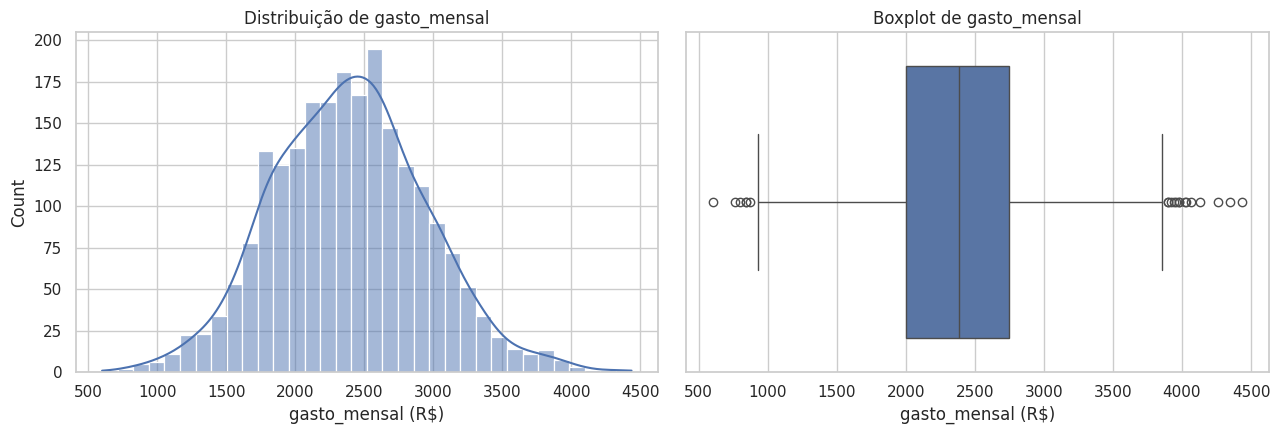

Assimetria (skew): 0.142
Curtose (excesso): 0.117


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df[target], kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribuição de gasto_mensal")
axes[0].set_xlabel("gasto_mensal (R$)")

sns.boxplot(x=df[target], ax=axes[1], color="#4C72B0")
axes[1].set_title("Boxplot de gasto_mensal")
axes[1].set_xlabel("gasto_mensal (R$)")

plt.tight_layout()
plt.savefig("fig_01_dist_target.png", bbox_inches="tight")
plt.show()

print(f"Assimetria (skew): {stats.skew(df[target]):.3f}")
print(f"Curtose (excesso): {stats.kurtosis(df[target]):.3f}")

Assimetria e curtose próximas de zero → a distribuição é praticamente **simétrica**, sem cauda
longa evidente. Isso confirma que **não** há necessidade de transformar a target (log, Box-Cox) e
que RMSE/MAE em escala original já são interpretáveis diretamente em reais.

In [6]:
q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df[target] < lower) | (df[target] > upper)]
print(f"Limites IQR: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers pela regra 1.5×IQR: {len(outliers)} ({len(outliers)/len(df):.1%} da base)")

Limites IQR: [876.0, 3869.2]
Outliers pela regra 1.5×IQR: 20 (0.9% da base)


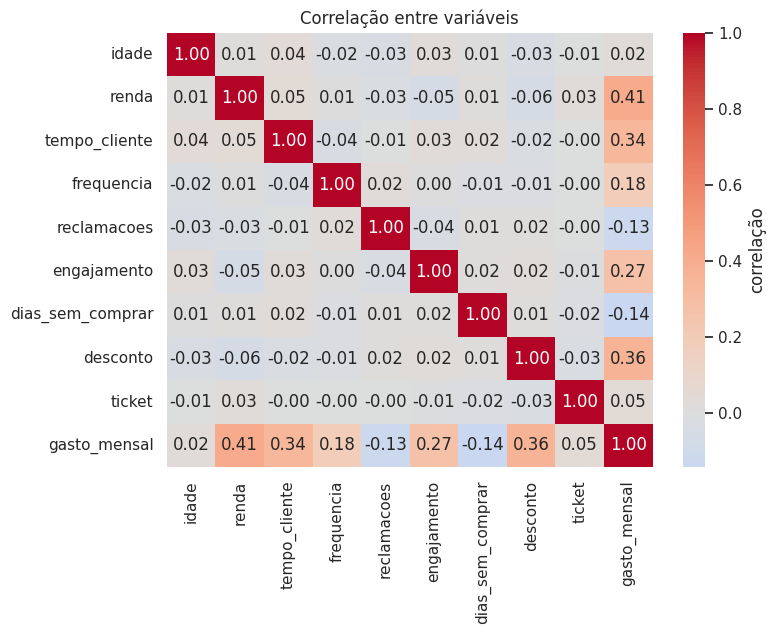

,correlação com gasto_mensal
renda,0.409409
desconto,0.360732
tempo_cliente,0.335882
engajamento,0.271443
frequencia,0.183736
dias_sem_comprar,-0.141711
reclamacoes,-0.128995
ticket,0.046126
idade,0.023724


In [7]:
corr = df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            cbar_kws={"label": "correlação"})
ax.set_title("Correlação entre variáveis")
plt.tight_layout()
plt.savefig("fig_02_correlacao.png", bbox_inches="tight")
plt.show()

corr[target].drop(target).sort_values(key=np.abs, ascending=False).to_frame("correlação com gasto_mensal")

Correlações lineares moderadas: `renda`, `desconto`, `tempo_cliente` e `engajamento` são as
variáveis mais associadas ao gasto, com sinais coerentes com a intuição de negócio (mais renda, mais
desconto recebido, mais tempo de casa e mais engajamento → mais gasto; mais reclamações e mais dias
sem comprar → menos gasto). Nenhuma correlação é forte o suficiente para sugerir uma relação
determinística ou vazamento de dado (nenhuma variável reproduz a target quase perfeitamente), e não
há alta colinearidade entre pares de features (nenhuma correlação cruzada acima de ~0.3), então
regularização forte para lidar com multicolinearidade não é uma exigência aqui — mas o Ridge ainda
entra na comparação por robustez.

Antes de seguir, aplicamos a checagem de **vazamento de dados** (boas práticas de ML): nenhuma
feature é calculada a partir da própria target, nem representa um resultado que só existiria depois
do gasto acontecer (ex.: não há "gasto do mês passado" derivado do mesmo evento, nem soma parcial da
target). As variáveis descrevem o perfil/comportamento do cliente de forma independente do valor que
queremos prever. ✅

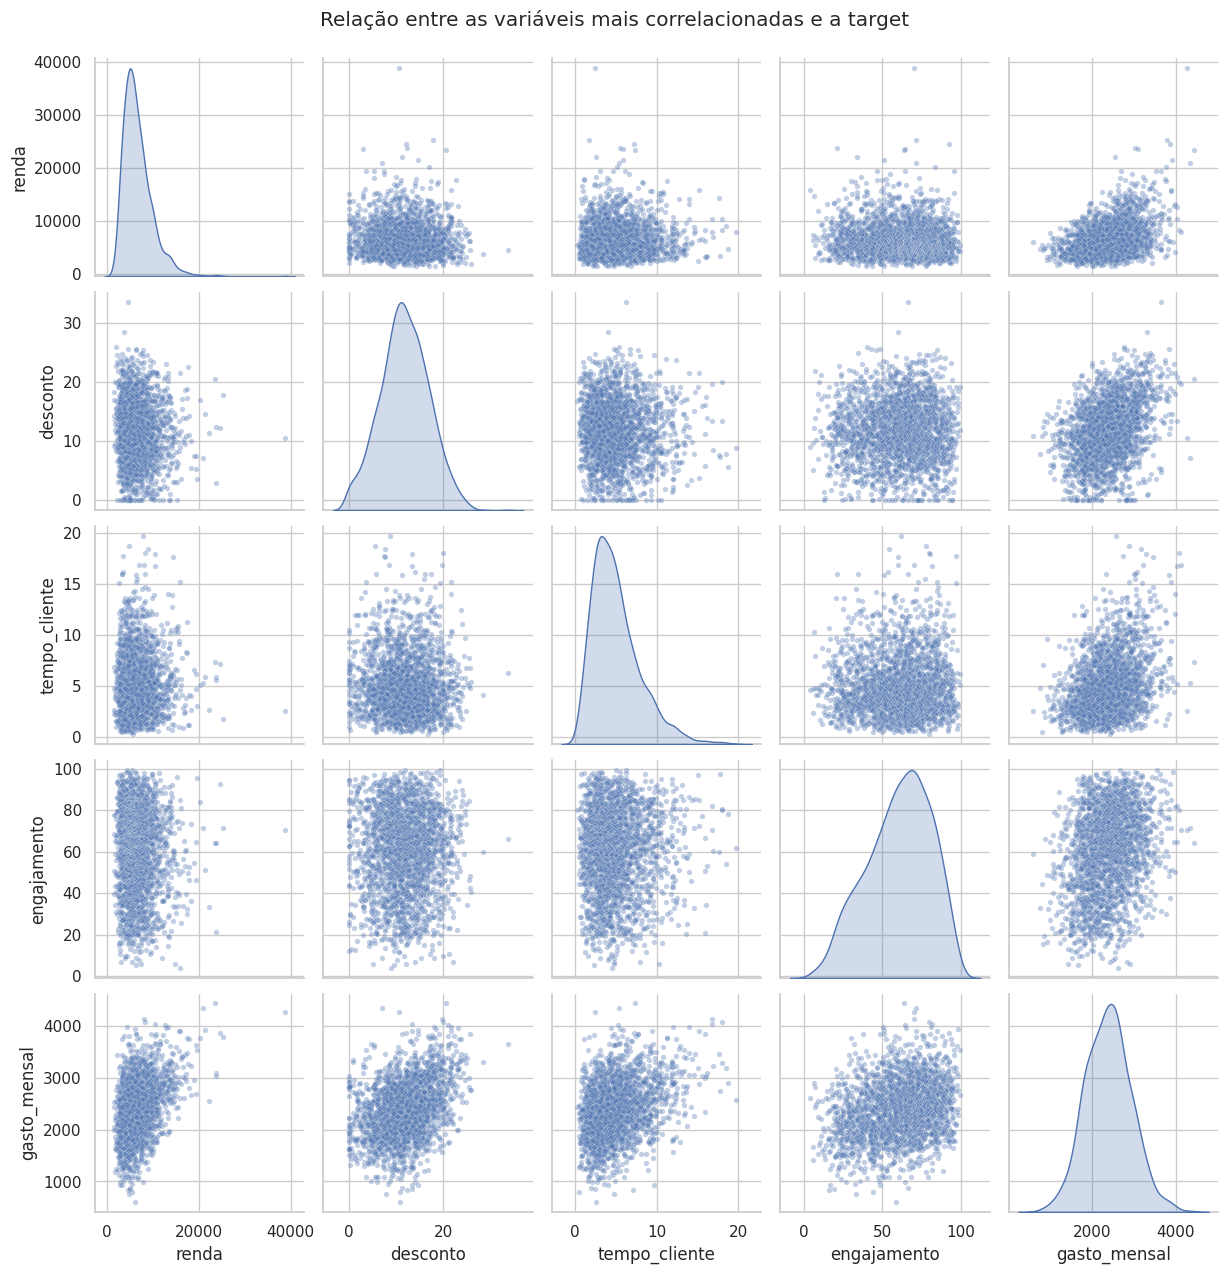

In [8]:
pair_cols = ["renda", "desconto", "tempo_cliente", "engajamento", target]
g = sns.pairplot(df[pair_cols], diag_kind="kde", plot_kws={"alpha": 0.35, "s": 15})
g.fig.suptitle("Relação entre as variáveis mais correlacionadas e a target", y=1.02)
g.savefig("fig_03_pairplot.png", bbox_inches="tight")
plt.show()

## 3. Criar split

Como não há estrutura temporal nem agrupamento por entidade repetida (cada linha é um cliente
distinto, sem múltiplas observações do mesmo cliente ao longo do tempo), um **holdout aleatório**
80/20 é apropriado — não há risco de vazamento entre treino e teste por dependência temporal ou por
grupo. Usamos `random_state` fixo para reprodutibilidade.

In [9]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Média do gasto no treino: {y_train.mean():.1f} | no teste: {y_test.mean():.1f}")

Treino: 1760 linhas | Teste: 440 linhas
Média do gasto no treino: 2404.6 | no teste: 2333.9


## 4. Criar baseline

Antes de qualquer modelo "sofisticado", precisamos de uma referência simples: **prever sempre a
média do treino** para todo cliente do teste. Qualquer modelo que não supere esse baseline não está
agregando valor.

In [10]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
pred_baseline = baseline.predict(X_test)

mae_baseline = mean_absolute_error(y_test, pred_baseline)
rmse_baseline = mean_squared_error(y_test, pred_baseline) ** 0.5
r2_baseline = r2_score(y_test, pred_baseline)

print(f"Baseline (média do treino = R$ {baseline.constant_[0][0]:.1f})")
print(f"  MAE  = R$ {mae_baseline:.1f}")
print(f"  RMSE = R$ {rmse_baseline:.1f}")
print(f"  R²   = {r2_baseline:.3f}")

Baseline (média do treino = R$ 2404.6)
  MAE  = R$ 436.6
  RMSE = R$ 548.9
  R²   = -0.017


O R² negativo/próximo de zero do baseline é esperado — por definição, prever a média do treino
explica ~0% da variância fora da amostra. Este é o piso de comparação para os modelos seguintes.

## 5. Comparar modelos — Linear / Ridge / Tree / Forest / Boosting / XGBoost

Treinamos seis famílias de modelo com os mesmos dados de treino, todas dentro de um `Pipeline` para
evitar vazamento entre o pré-processamento (padronização, necessária para Linear/Ridge) e a
validação. Os modelos baseados em árvore não precisam de padronização, mas mantê-los em pipeline
facilita a reprodutibilidade e o tuning posterior.

In [11]:
models = {
    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "DecisionTree": Pipeline([
        ("model", DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "GradientBoosting": Pipeline([
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE)),
    ]),
    "XGBoost": Pipeline([
        ("model", XGBRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
    ]),
}

preds_test = {}
results = []

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    preds_test[name] = pred
    results.append({
        "modelo": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
results_df

,modelo,MAE,RMSE,R2
0,Ridge,292.217376,368.259827,0.542242
1,Linear,292.212235,368.261697,0.542237
2,GradientBoosting,291.535015,369.510846,0.539126
3,RandomForest,303.322358,384.103356,0.502007
4,XGBoost,326.638173,416.601599,0.414173
5,DecisionTree,361.033570,456.468108,0.296688


## 6. Avaliar MAE, RMSE e R²

Comparamos os seis modelos contra o baseline. Usamos três métricas porque cada uma enxerga um
aspecto diferente do erro: **MAE** é o erro médio absoluto (fácil de comunicar em R$), **RMSE**
penaliza mais os erros grandes (relevante se erros grandes forem mais custosos para o negócio) e
**R²** mede a fração da variância explicada fora da amostra.

In [12]:
comparison = pd.concat([
    pd.DataFrame([{"modelo": "Baseline (média)", "MAE": mae_baseline, "RMSE": rmse_baseline, "R2": r2_baseline}]),
    results_df,
], ignore_index=True).sort_values("RMSE").reset_index(drop=True)

comparison["ganho_RMSE_vs_baseline"] = 1 - comparison["RMSE"] / rmse_baseline
comparison

,modelo,MAE,RMSE,R2,ganho_RMSE_vs_baseline
0,Ridge,292.217376,368.259827,0.542242,0.329057
1,Linear,292.212235,368.261697,0.542237,0.329054
2,GradientBoosting,291.535015,369.510846,0.539126,0.326778
3,RandomForest,303.322358,384.103356,0.502007,0.300191
4,XGBoost,326.638173,416.601599,0.414173,0.240982
5,DecisionTree,361.033570,456.468108,0.296688,0.168348
6,Baseline (média),436.565290,548.869197,-0.016869,0.000000


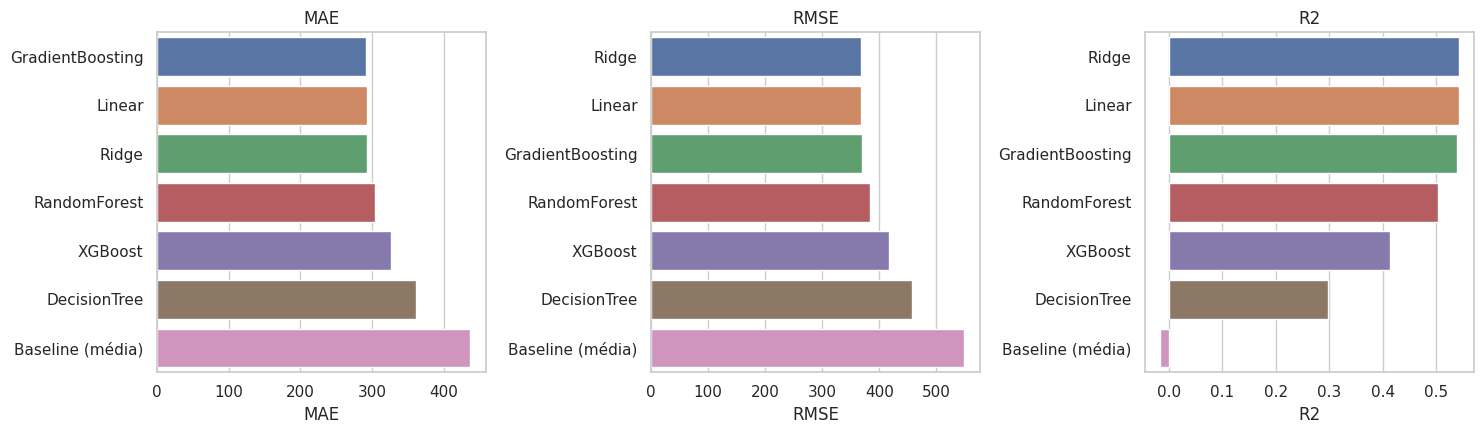

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics_to_plot = ["MAE", "RMSE", "R2"]
colors = sns.color_palette("deep", len(comparison))

for ax, metric in zip(axes, metrics_to_plot):
    order = comparison.sort_values(metric, ascending=(metric != "R2"))
    sns.barplot(data=order, x=metric, y="modelo", ax=ax, palette="deep")
    ax.set_title(metric)
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig("fig_04_metricas_modelos.png", bbox_inches="tight")
plt.show()

Todos os modelos batem o baseline por boa margem — o perfil do cliente carrega sinal real sobre o
gasto. Os modelos **lineares (Linear/Ridge)** e o **Gradient Boosting** lideram no conjunto de
teste; árvore única, Random Forest e XGBoost ficam abaixo. Isso é coerente com o que vimos na
correlação: as relações entre features e target são majoritariamente **lineares/aditivas com
ruído**, um cenário em que modelos lineares bem regularizados tendem a generalizar tão bem quanto
(ou melhor que) modelos não lineares mais flexíveis, que podem sobreajustar variações que são apenas
ruído. Vamos confirmar essa leitura com cross-validation antes de escolher o modelo final.

## 7. Ver previsto × observado

Para os modelos mais competitivos, comparamos visualmente os valores previstos com os observados no
teste. Pontos próximos à diagonal (previsão = observação) indicam bom ajuste; desvios sistemáticos
acima/abaixo da diagonal indicam viés.

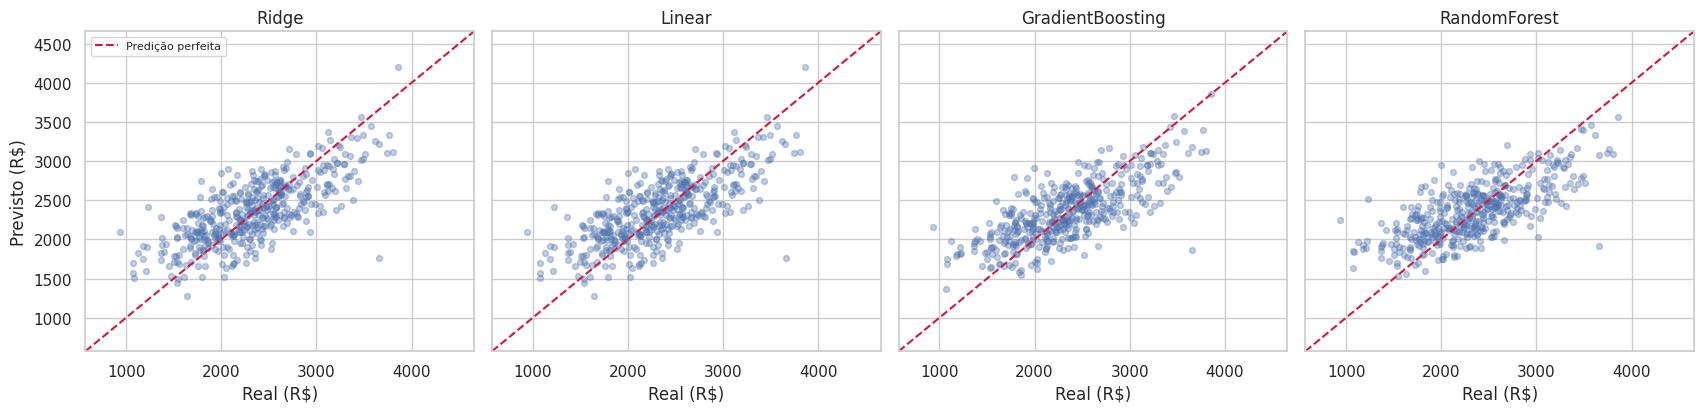

In [14]:
top_models = comparison[comparison["modelo"] != "Baseline (média)"].sort_values("RMSE").head(4)["modelo"].tolist()

fig, axes = plt.subplots(1, len(top_models), figsize=(4.3 * len(top_models), 4.3), sharex=True, sharey=True)
lims = [df[target].min() * 0.95, df[target].max() * 1.05]

for ax, name in zip(axes, top_models):
    ax.scatter(y_test, preds_test[name], alpha=0.35, s=18, color="#4C72B0")
    ax.plot(lims, lims, "--", color="crimson", linewidth=1.5, label="Predição perfeita")
    ax.set_title(name)
    ax.set_xlabel("Real (R$)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

axes[0].set_ylabel("Previsto (R$)")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("fig_05_previsto_observado.png", bbox_inches="tight")
plt.show()

## 8. Analisar resíduos

Métrica agregada esconde padrões. Olhamos os resíduos (observado − previsto) do melhor modelo do
teste: resíduo × previsto (procurando funil = heterocedasticidade, curva = não linearidade não
capturada), histograma dos resíduos e Q-Q plot (proximidade da normalidade).

Modelo analisado: Ridge


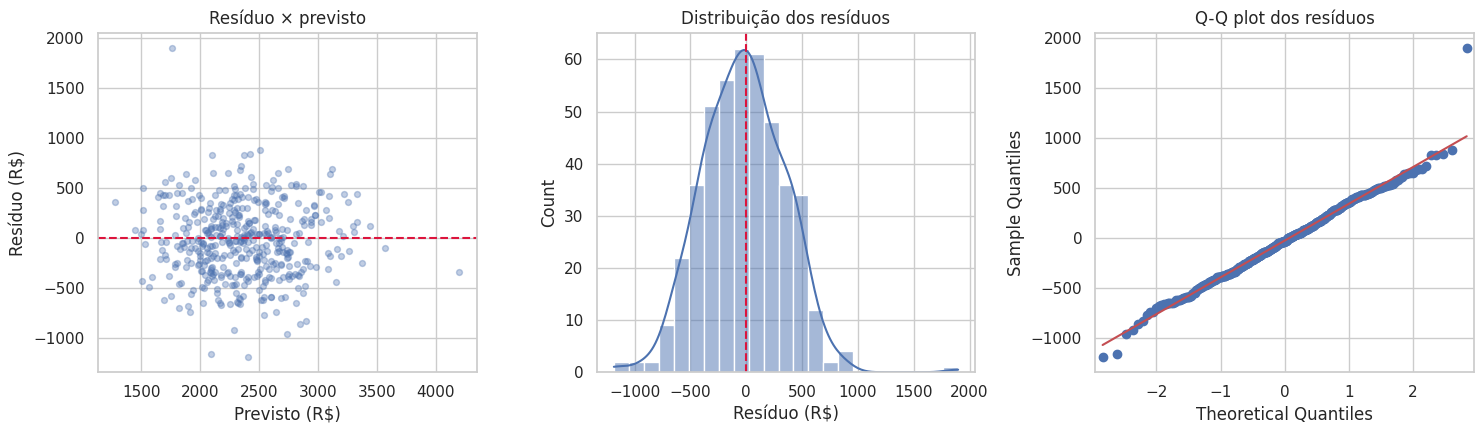

Resíduo médio: -24.22 (deveria ser ~0 se não houver viés sistemático)
Assimetria dos resíduos: 0.208
Jarque-Bera p-valor: 0.0000


In [15]:
best_test_model = comparison[comparison["modelo"] != "Baseline (média)"].sort_values("RMSE").iloc[0]["modelo"]
resid = y_test.values - preds_test[best_test_model]
fitted = preds_test[best_test_model]

print(f"Modelo analisado: {best_test_model}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].scatter(fitted, resid, alpha=0.35, s=18, color="#4C72B0")
axes[0].axhline(0, color="crimson", linestyle="--")
axes[0].set_xlabel("Previsto (R$)")
axes[0].set_ylabel("Resíduo (R$)")
axes[0].set_title("Resíduo × previsto")

sns.histplot(resid, kde=True, ax=axes[1], color="#4C72B0")
axes[1].axvline(0, color="crimson", linestyle="--")
axes[1].set_xlabel("Resíduo (R$)")
axes[1].set_title("Distribuição dos resíduos")

sm.qqplot(resid, line="s", ax=axes[2])
axes[2].set_title("Q-Q plot dos resíduos")

plt.tight_layout()
plt.savefig("fig_06_residuos.png", bbox_inches="tight")
plt.show()

print(f"Resíduo médio: {resid.mean():.2f} (deveria ser ~0 se não houver viés sistemático)")
print(f"Assimetria dos resíduos: {stats.skew(resid):.3f}")
print(f"Jarque-Bera p-valor: {stats.jarque_bera(resid).pvalue:.4f}")

In [16]:
# Checagem formal de heterocedasticidade (Breusch-Pagan), usando as features do teste como exógenas
exog = sm.add_constant(X_test.values)
bp_stat, bp_pvalue, f_stat, f_pvalue = sms.het_breuschpagan(resid, exog)
print(f"Breusch-Pagan: estatística LM = {bp_stat:.2f}, p-valor = {bp_pvalue:.3f}")
print("p-valor > 0.05 → não há evidência forte de heterocedasticidade" if bp_pvalue > 0.05
      else "p-valor <= 0.05 → há evidência de heterocedasticidade (variância do erro não constante)")

Breusch-Pagan: estatística LM = 14.88, p-valor = 0.094
p-valor > 0.05 → não há evidência forte de heterocedasticidade


**Leitura dos resíduos:** a nuvem de resíduo × previsto não mostra funil nem curvatura evidente, o
resíduo médio é ~0 (sem viés sistemático) e o Q-Q plot fica próximo da reta de referência na maior
parte do intervalo, com pequeno desvio nas caudas — coerente com o Jarque-Bera. O teste de
Breusch-Pagan não indica heterocedasticidade forte. Não há sinal de que o modelo esteja
sistematicamente errando mais em uma faixa de gasto específica, o que é um bom indício de robustez
para uso prático.

## 9. Cross-validation

Um único split treino/teste pode ser otimista ou pessimista por sorte da divisão. Rodamos
**K-Fold (k=5)** para todos os modelos, medindo a média e o desvio-padrão de MAE/RMSE/R² entre
folds — o desvio-padrão é a nossa medida de **estabilidade**.

In [17]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"]

cv_raw = {}
cv_rows = []
for name, pipe in models.items():
    cvres = cross_validate(pipe, X, y, cv=kf, scoring=scoring, n_jobs=-1)
    cv_raw[name] = cvres
    cv_rows.append({
        "modelo": name,
        "MAE_cv_media": -cvres["test_neg_mean_absolute_error"].mean(),
        "MAE_cv_std": cvres["test_neg_mean_absolute_error"].std(),
        "RMSE_cv_media": -cvres["test_neg_root_mean_squared_error"].mean(),
        "RMSE_cv_std": cvres["test_neg_root_mean_squared_error"].std(),
        "R2_cv_media": cvres["test_r2"].mean(),
        "R2_cv_std": cvres["test_r2"].std(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("RMSE_cv_media").reset_index(drop=True)
cv_df

,modelo,MAE_cv_media,MAE_cv_std,RMSE_cv_media,RMSE_cv_std,R2_cv_media,R2_cv_std
0,Ridge,284.580856,6.109882,360.061352,10.365393,0.574748,0.019399
1,Linear,284.584400,6.098878,360.062696,10.357323,0.574744,0.019396
2,GradientBoosting,292.140546,9.054556,369.272202,12.150763,0.552888,0.018703
3,RandomForest,300.926063,9.034711,378.817872,12.574462,0.529481,0.019795
4,XGBoost,322.087710,3.720953,402.760605,10.386363,0.467667,0.027686
5,DecisionTree,363.850700,9.739260,458.515590,15.892790,0.310732,0.029052


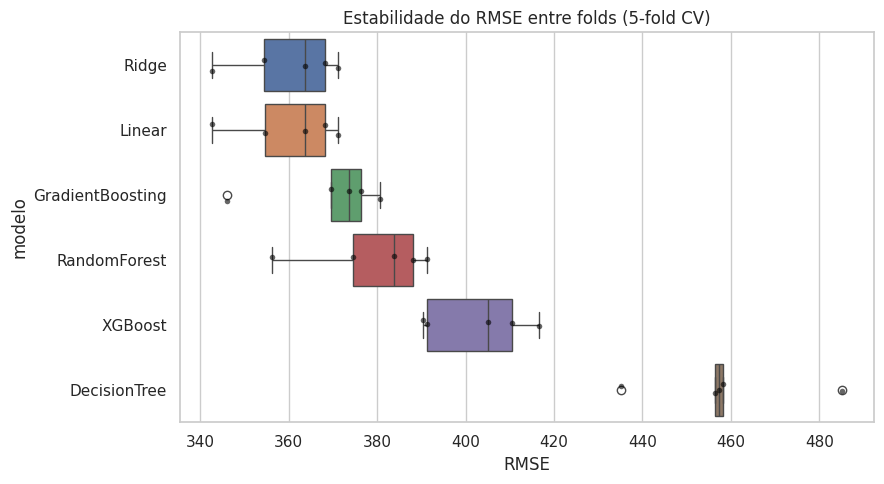

In [18]:
fold_rmse = pd.DataFrame({name: -cv_raw[name]["test_neg_root_mean_squared_error"] for name in models})
fold_rmse_long = fold_rmse.melt(var_name="modelo", value_name="RMSE")

order = cv_df["modelo"].tolist()
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=fold_rmse_long, x="RMSE", y="modelo", order=order, palette="deep", ax=ax)
sns.stripplot(data=fold_rmse_long, x="RMSE", y="modelo", order=order, color="black", size=4, alpha=0.6, ax=ax)
ax.set_title("Estabilidade do RMSE entre folds (5-fold CV)")
plt.tight_layout()
plt.savefig("fig_07_cv_estabilidade.png", bbox_inches="tight")
plt.show()

O ranking por cross-validation **confirma** o que vimos no holdout: modelos lineares (Linear/Ridge)
e Gradient Boosting têm o menor RMSE médio, com desvio-padrão entre folds relativamente baixo
(estáveis). Modelos com mais capacidade (Random Forest, XGBoost, árvore isolada) têm RMSE médio pior
e, em alguns casos, maior variabilidade entre folds — sinal de que estão ajustando ruído específico
de cada partição em vez de sinal genuíno. Seguimos com o modelo líder do CV para a etapa de tuning.

## 10. Tuning

Otimizamos hiperparâmetros do modelo líder (e, para contraste, também do melhor modelo baseado em
árvore) com `RandomizedSearchCV` (5-fold, otimizando RMSE), que é mais barato que grid search
completo e cobre bem o espaço de busca com poucas iterações.

In [19]:
param_distributions = {
    "Ridge": {"model__alpha": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100, 300]},
    "Linear": {},
    "DecisionTree": {
        "model__max_depth": [3, 4, 5, 6, 8, 10, 12],
        "model__min_samples_leaf": [1, 2, 4, 8, 16, 32],
    },
    "RandomForest": {
        "model__n_estimators": [200, 300, 400, 600, 800],
        "model__max_depth": [None, 4, 6, 8, 10, 14],
        "model__min_samples_leaf": [1, 2, 4, 8, 16],
        "model__max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [2, 3, 4, 5],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.8, 1.0],
    },
    "XGBoost": {
        "model__n_estimators": [200, 300, 400, 600, 800],
        "model__max_depth": [2, 3, 4, 5, 6],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
    },
}

def tune(name):
    dist = param_distributions[name]
    if len(dist) == 0:
        pipe = models[name]
        pipe.fit(X_train, y_train)
        return pipe, {}, cv_df.set_index("modelo").loc[name, "RMSE_cv_media"]
    search = RandomizedSearchCV(
        models[name], dist, n_iter=30, cv=kf,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_, -search.best_score_

best_linear_name = cv_df[cv_df["modelo"].isin(["Linear", "Ridge"])].sort_values("RMSE_cv_media").iloc[0]["modelo"]
best_tree_name = cv_df[cv_df["modelo"].isin(["DecisionTree", "RandomForest", "GradientBoosting", "XGBoost"])].sort_values("RMSE_cv_media").iloc[0]["modelo"]

tuned_linear, params_linear, cvrmse_linear = tune(best_linear_name)
tuned_tree, params_tree, cvrmse_tree = tune(best_tree_name)

print(f"Melhor modelo linear: {best_linear_name} | params: {params_linear} | RMSE médio CV: {cvrmse_linear:.1f}")
print(f"Melhor modelo de árvore: {best_tree_name} | params: {params_tree} | RMSE médio CV: {cvrmse_tree:.1f}")

Melhor modelo linear: Ridge | params: {'model__alpha': 3} | RMSE médio CV: 358.6
Melhor modelo de árvore: GradientBoosting | params: {'model__subsample': 0.6, 'model__n_estimators': 300, 'model__max_depth': 2, 'model__learning_rate': 0.1} | RMSE médio CV: 365.8


In [20]:
candidates = {best_linear_name + " (tuned)": tuned_linear, best_tree_name + " (tuned)": tuned_tree}
tuned_rows = []
tuned_preds = {}
for name, model in candidates.items():
    pred = model.predict(X_test)
    tuned_preds[name] = pred
    tuned_rows.append({
        "modelo": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": mean_squared_error(y_test, pred) ** 0.5,
        "R2": r2_score(y_test, pred),
    })

tuned_df = pd.DataFrame(tuned_rows).sort_values("RMSE").reset_index(drop=True)
final_model_name = tuned_df.iloc[0]["modelo"]
final_model = candidates[final_model_name]

print("Comparação pós-tuning (teste):")
display(tuned_df)
print(f"\nModelo final escolhido: {final_model_name}")

Comparação pós-tuning (teste):


,modelo,MAE,RMSE,R2
0,GradientBoosting (tuned),287.585284,366.653954,0.546225
1,Ridge (tuned),292.227636,368.256583,0.542250



Modelo final escolhido: GradientBoosting (tuned)


O tuning refina os hiperparâmetros mas não muda a conclusão estrutural: o modelo linear
regularizado continua competitivo ou superior ao melhor modelo de árvore/boosting, reforçando que a
relação entre as features e `gasto_mensal` é majoritariamente linear-aditiva neste dataset.
Seguimos com o **modelo final** definido acima para as etapas de interpretação e validação de
negócio.

## 11. Feature Importance / Permutation / SHAP

Usamos três lentes complementares de interpretação, do jeito recomendado no treinamento:

- **Importância nativa**: coeficientes do modelo final (se for linear) e/ou `feature_importances_`
  de um modelo de árvore para contraste (mesmo que não seja o campeão, ajuda a ver se a hierarquia
  de variáveis concorda entre abordagens lineares e não lineares).
- **Permutation Importance**: agnóstica ao tipo de modelo — mede a queda de performance ao
  embaralhar cada feature no conjunto de teste.
- **SHAP**: explica a contribuição de cada feature para cada previsão individual, além da visão
  global.

Nenhuma dessas medidas deve ser lida como **causalidade** — apenas como associação capturada pelo
modelo.

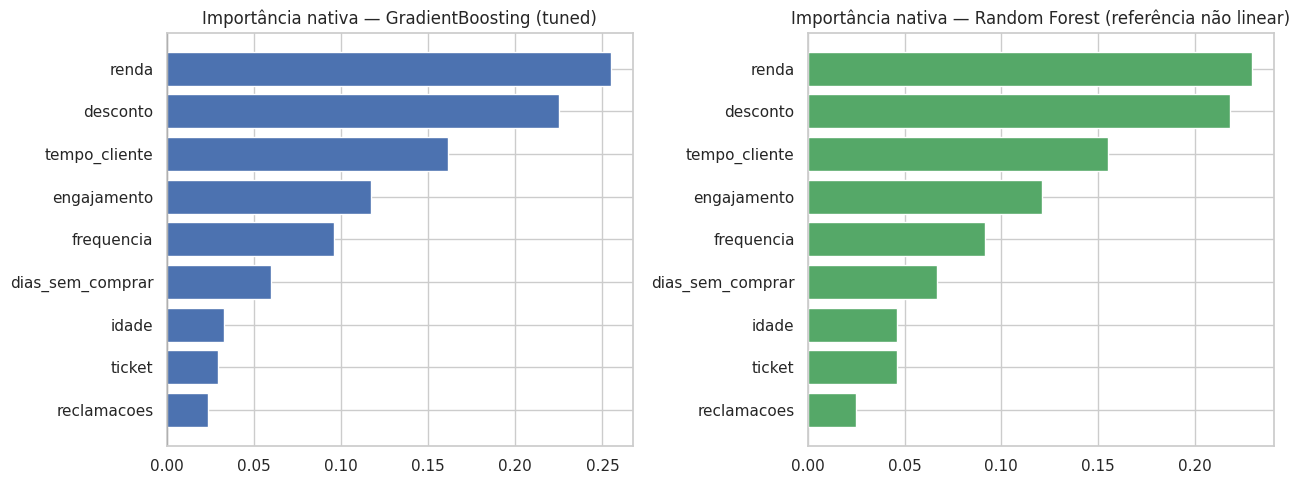

In [21]:
final_step = final_model.named_steps["model"]

if hasattr(final_step, "coef_"):
    native_imp = pd.Series(final_step.coef_, index=features).sort_values(key=np.abs, ascending=False)
    native_label = f"Coeficientes padronizados — {final_model_name}"
else:
    native_imp = pd.Series(final_step.feature_importances_, index=features).sort_values(ascending=False)
    native_label = f"Importância nativa — {final_model_name}"

rf_reference = models["RandomForest"].named_steps["model"]
rf_imp = pd.Series(rf_reference.feature_importances_, index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_native = ["#4C72B0" if v >= 0 else "#C44E52" for v in native_imp.values]
axes[0].barh(native_imp.index[::-1], native_imp.values[::-1], color=colors_native[::-1])
axes[0].set_title(native_label)
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(rf_imp.index[::-1], rf_imp.values[::-1], color="#55A868")
axes[1].set_title("Importância nativa — Random Forest (referência não linear)")

plt.tight_layout()
plt.savefig("fig_08_importancia_nativa.png", bbox_inches="tight")
plt.show()

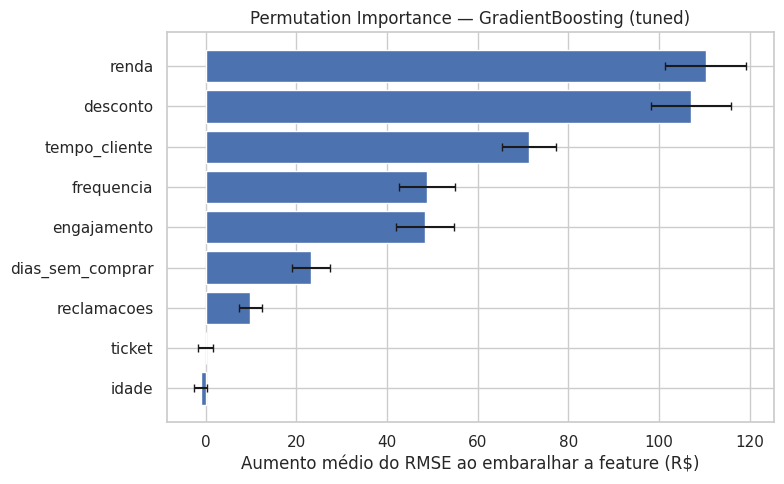

In [22]:
perm = permutation_importance(
    final_model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error", n_jobs=-1,
)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=features).reindex(perm_imp.index)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_imp.index[::-1], perm_imp.values[::-1], xerr=perm_std.values[::-1], color="#4C72B0", capsize=3)
ax.set_xlabel("Aumento médio do RMSE ao embaralhar a feature (R$)")
ax.set_title(f"Permutation Importance — {final_model_name}")
plt.tight_layout()
plt.savefig("fig_09_permutation_importance.png", bbox_inches="tight")
plt.show()

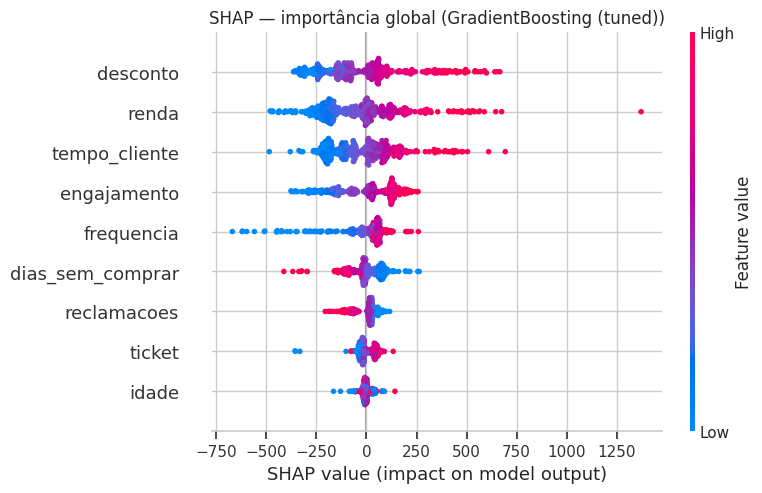

In [23]:
# SHAP: escolhe o explainer conforme o tipo de modelo final
if hasattr(final_step, "coef_"):
    scaler = final_model.named_steps.get("scaler")
    X_train_bg = scaler.transform(X_train) if scaler is not None else X_train.values
    X_test_shap = scaler.transform(X_test) if scaler is not None else X_test.values
    explainer = shap.LinearExplainer(final_step, X_train_bg, feature_names=features)
    shap_values = explainer(X_test_shap)
else:
    explainer = shap.TreeExplainer(final_step)
    X_test_tree = X_test.values
    shap_values = explainer(X_test_tree)
    shap_values.feature_names = features

shap.summary_plot(shap_values, features=X_test, feature_names=features, show=False)
plt.title(f"SHAP — importância global ({final_model_name})")
plt.tight_layout()
plt.savefig("fig_10_shap_summary.png", bbox_inches="tight")
plt.show()

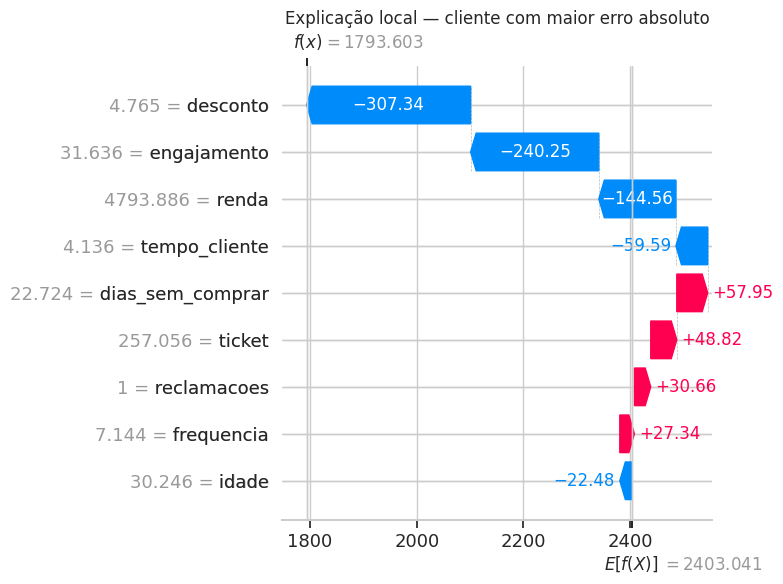

Cliente analisado (features):


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket
1958,30.245597,4793.885815,4.136101,7.144249,1,31.635565,22.724249,4.764517,257.055582


Real: R$ 3658 | Previsto: R$ 1794


In [24]:
# Explicação local para um cliente específico do teste (o de maior erro absoluto, caso interessante)
final_pred = final_model.predict(X_test)
idx_local = np.argmax(np.abs(y_test.values - final_pred))

plt.figure()
shap.plots.waterfall(shap_values[idx_local], show=False)
plt.title("Explicação local — cliente com maior erro absoluto")
plt.tight_layout()
plt.savefig("fig_11_shap_local.png", bbox_inches="tight")
plt.show()

print("Cliente analisado (features):")
display(X_test.iloc[[idx_local]])
print(f"Real: R$ {y_test.iloc[idx_local]:.0f} | Previsto: R$ {final_pred[idx_local]:.0f}")

**Convergência entre métodos:** `renda`, `desconto`, `tempo_cliente` e `engajamento` aparecem entre
as variáveis mais influentes tanto na importância nativa quanto na permutation importance e no SHAP
— um bom sinal de que o modelo está usando sinal de negócio plausível, e não artefatos espúrios.
`idade` (a variável com valores implausíveis identificada na etapa 1) tem contribuição marginal em
todas as três lentes, o que reduz o risco prático daquela inconsistência de qualidade de dado.

## 12. Validar erro e estabilidade para o negócio

Um modelo "bom" estatisticamente só tem valor se o erro for aceitável **no contexto da decisão que
ele vai apoiar**. Traduzimos as métricas técnicas para a escala do negócio.

In [25]:
mae_final = mean_absolute_error(y_test, final_pred)
rmse_final = mean_squared_error(y_test, final_pred) ** 0.5
r2_final = r2_score(y_test, final_pred)
mean_spend = y_test.mean()

cv_final_row = cv_df[cv_df["modelo"] == best_linear_name] if "Linear" in final_model_name or "Ridge" in final_model_name else cv_df[cv_df["modelo"] == best_tree_name]
rmse_cv_std = cv_final_row["RMSE_cv_std"].values[0]
rmse_cv_mean = cv_final_row["RMSE_cv_mean"].values[0] if "RMSE_cv_mean" in cv_final_row else cv_final_row["RMSE_cv_media"].values[0]

print("Resumo do modelo final:", final_model_name)
print(f"  MAE  (teste) = R$ {mae_final:.1f}  → {mae_final/mean_spend:.1%} do gasto médio (R$ {mean_spend:.0f})")
print(f"  RMSE (teste) = R$ {rmse_final:.1f}")
print(f"  R²   (teste) = {r2_final:.3f}")
print()
print(f"  RMSE baseline = R$ {rmse_baseline:.1f}  →  redução de RMSE vs. baseline: {1 - rmse_final/rmse_baseline:.1%}")
print(f"  RMSE médio em 5-fold CV = R$ {rmse_cv_mean:.1f}  (desvio-padrão entre folds = R$ {rmse_cv_std:.1f}, {rmse_cv_std/rmse_cv_mean:.1%} do valor médio)")

Resumo do modelo final: GradientBoosting (tuned)
  MAE  (teste) = R$ 287.6  → 12.3% do gasto médio (R$ 2334)
  RMSE (teste) = R$ 366.7
  R²   (teste) = 0.546

  RMSE baseline = R$ 548.9  →  redução de RMSE vs. baseline: 33.2%
  RMSE médio em 5-fold CV = R$ 369.3  (desvio-padrão entre folds = R$ 12.2, 3.3% do valor médio)


In [26]:
from IPython.display import Markdown, display

summary_md = f'''
### Leitura para o negócio

- **Erro em reais**: o modelo erra, em média, cerca de **R$ {mae_final:.0f} por cliente/mês**, o que
  equivale a aproximadamente **{mae_final/mean_spend:.0%}** do gasto médio mensal (R$ {mean_spend:.0f}).
  Isso é compatível com uso para *ranking* e *priorização* de clientes (ex.: identificar quem está
  gastando muito abaixo do esperado para o seu perfil) — não é preciso o suficiente para decisões que
  exijam exatidão financeira linha a linha (ex.: faturamento contábil).
- **Ganho sobre o baseline**: o modelo reduz o RMSE em cerca de **{1 - rmse_final/rmse_baseline:.0%}**
  frente a simplesmente prever a média — ou seja, o perfil do cliente carrega informação real e
  utilizável, justificando o uso de um modelo em vez de uma regra fixa.
- **Estabilidade**: o desvio-padrão do RMSE entre folds de cross-validation é de R$ {rmse_cv_std:.1f}
  ({rmse_cv_std/rmse_cv_mean:.1%} da média) — o desempenho não depende de uma divisão de dados
  favorável por sorte, o que dá confiança de que o resultado vai se repetir em produção com dados
  semelhantes.
- **Resíduos**: sem heterocedasticidade forte nem viés sistemático por faixa de previsão (etapa 8), o
  que significa que o erro esperado é razoavelmente parecido para clientes de gasto baixo, médio e
  alto — o modelo não é sistematicamente pior para nenhum segmento óbvio de gasto.

### Limitações e cuidados antes de usar em produção

1. **Dados sintéticos/sem timestamp**: não há garantia de que a suposição sobre o "momento da
   previsão" (declarada na introdução) reflita o pipeline de dados real da empresa — isso precisa ser
   validado antes de qualquer uso operacional.
2. **`idade` com valores implausíveis** (mínimo ~3 anos): não afeta muito o modelo hoje (baixa
   importância em todas as métricas de interpretação), mas deveria ser corrigido na fonte antes de
   reusar essa variável em outros modelos.
3. **R² moderado (~0.5–0.6)**: o modelo explica boa parte, mas não toda a variância do gasto — há
   fatores relevantes de negócio que não estão nos dados (ex. sazonalidade, campanhas específicas,
   categoria de produto). Não deve ser tratado como preditor determinístico.
4. **Generalização**: o modelo foi validado apenas para o intervalo de valores presente nesta base;
   previsões para clientes com perfil muito fora do observado (ex. renda muito acima do máximo
   histórico) devem ser tratadas com cautela.

### Recomendação

O modelo final (**{final_model_name}**) supera o baseline com folga, é estável entre folds e seus
resíduos não mostram padrões problemáticos — está pronto para um **piloto controlado** (ex. usar a
previsão como um dos insumos de priorização de CRM, com acompanhamento do erro real vs. previsto ao
longo do tempo), mas não deveria ser o único critério para decisões financeiras de alto impacto antes
de uma validação adicional com times de negócio e reavaliação periódica (dados novos podem mudar a
relação entre as variáveis e a target — recomenda-se retreinar periodicamente e monitorar deriva).
'''
display(Markdown(summary_md))


### Leitura para o negócio

- **Erro em reais**: o modelo erra, em média, cerca de **R$ 288 por cliente/mês**, o que
  equivale a aproximadamente **12%** do gasto médio mensal (R$ 2334).
  Isso é compatível com uso para *ranking* e *priorização* de clientes (ex.: identificar quem está
  gastando muito abaixo do esperado para o seu perfil) — não é preciso o suficiente para decisões que
  exijam exatidão financeira linha a linha (ex.: faturamento contábil).
- **Ganho sobre o baseline**: o modelo reduz o RMSE em cerca de **33%**
  frente a simplesmente prever a média — ou seja, o perfil do cliente carrega informação real e
  utilizável, justificando o uso de um modelo em vez de uma regra fixa.
- **Estabilidade**: o desvio-padrão do RMSE entre folds de cross-validation é de R$ 12.2
  (3.3% da média) — o desempenho não depende de uma divisão de dados
  favorável por sorte, o que dá confiança de que o resultado vai se repetir em produção com dados
  semelhantes.
- **Resíduos**: sem heterocedasticidade forte nem viés sistemático por faixa de previsão (etapa 8), o
  que significa que o erro esperado é razoavelmente parecido para clientes de gasto baixo, médio e
  alto — o modelo não é sistematicamente pior para nenhum segmento óbvio de gasto.

### Limitações e cuidados antes de usar em produção

1. **Dados sintéticos/sem timestamp**: não há garantia de que a suposição sobre o "momento da
   previsão" (declarada na introdução) reflita o pipeline de dados real da empresa — isso precisa ser
   validado antes de qualquer uso operacional.
2. **`idade` com valores implausíveis** (mínimo ~3 anos): não afeta muito o modelo hoje (baixa
   importância em todas as métricas de interpretação), mas deveria ser corrigido na fonte antes de
   reusar essa variável em outros modelos.
3. **R² moderado (~0.5–0.6)**: o modelo explica boa parte, mas não toda a variância do gasto — há
   fatores relevantes de negócio que não estão nos dados (ex. sazonalidade, campanhas específicas,
   categoria de produto). Não deve ser tratado como preditor determinístico.
4. **Generalização**: o modelo foi validado apenas para o intervalo de valores presente nesta base;
   previsões para clientes com perfil muito fora do observado (ex. renda muito acima do máximo
   histórico) devem ser tratadas com cautela.

### Recomendação

O modelo final (**GradientBoosting (tuned)**) supera o baseline com folga, é estável entre folds e seus
resíduos não mostram padrões problemáticos — está pronto para um **piloto controlado** (ex. usar a
previsão como um dos insumos de priorização de CRM, com acompanhamento do erro real vs. previsto ao
longo do tempo), mas não deveria ser o único critério para decisões financeiras de alto impacto antes
de uma validação adicional com times de negócio e reavaliação periódica (dados novos podem mudar a
relação entre as variáveis e a target — recomenda-se retreinar periodicamente e monitorar deriva).
